<a href="https://colab.research.google.com/github/Andre-831/AI-ML-Projects/blob/main/nbs/CSE142W6_Clustering_NN_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Disable Auto-writing (AI Assistance) in Google Colab:

1. **Open the Tools menu:** In the Colab notebook, go to the "Tools" tab located in the menu bar at the top of the screen.

2. **Access Settings:** From the "Tools" dropdown, select "Settings".

3. **Navigate to AI Assistance:** In the Settings window, choose "AI Assistance".

4. **Disable Generative AI Features:** You'll see a checkbox labeled "Consented to use generative AI features." Uncheck this option.

5. **Hide Generative AI Features (Optional):** You can also check the box next to "Hide generative AI features" for a more complete disabling of AI assistance features.

6. **Save Changes:** Once you've made your selections, go to the "File" tab and click "Save" to save the changes.

### Runtime Setup (Google Colab)

This notebook only requires **CPU** — no GPU needed.

1. Go to **Runtime** > **Change runtime type**
2. Set **Hardware accelerator** to **None** (CPU)
3. Click **Save**

Run the cell below to verify your environment.

In [ ]:
#@title Environment Check — Run this first!
import sys
import platform

print(f"Python version: {sys.version}")
print(f"Platform:       {platform.platform()}")

import numpy as np
print(f"NumPy version:  {np.__version__}")

import matplotlib
print(f"Matplotlib:     {matplotlib.__version__}")

import sklearn
print(f"scikit-learn:   {sklearn.__version__}")

try:
    import google.colab
    gpu_info = !nvidia-smi --query-gpu=name --format=csv,noheader 2>/dev/null
    if gpu_info and gpu_info[0].strip():
        print(f"\n⚠️  GPU detected: {gpu_info[0].strip()}")
        print("    This notebook only needs CPU. You may switch to save resources.")
    else:
        print(f"\n✅ Running on CPU — perfect for this assignment!")
except ImportError:
    print(f"\n(Not running on Google Colab — local environment detected)")

print("\n--- Environment OK. You may proceed. ---")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform:       Linux-6.6.113+-x86_64-with-glibc2.35
NumPy version:  2.0.2
Matplotlib:     3.10.0
scikit-learn:   1.6.1

✅ Running on CPU — perfect for this assignment!

--- Environment OK. You may proceed. ---


# CSE 142 — Week 6 Discussion: Clustering, Neural Nets & Midterm Review

This week you will (1) implement the inner loops of three algorithms from lectures 5-2 and 6-1, and (2) walk through a midterm retrospective for lectures 1–6.1.

**Part A — Hands-on (about 30 minutes)**
- **Q1.** K-means from scratch — `kmeans_assign(...)`, `kmeans_update(...)`, and a small training loop. Verify against `sklearn.cluster.KMeans`.
- **Q2.** GMM responsibilities (the *E-step*) — `gaussian_pdf(...)`, `gmm_responsibilities(...)`. Verify against `sklearn.mixture.GaussianMixture.predict_proba`.
- **Q3.** Neural-network forward pass — ReLU + sigmoid, replay the lecture-6-1 worked example, then solve XOR with hand-set weights.

**Part B — Midterm Retrospective (about 15 minutes)**
- A guided self-check covering linear regression, logistic regression, MLE/MAP, Naive Bayes, hard-margin SVM, K-means, EM, and the perceptron / NN forward pass.

Do **not** modify setup or test cells. Write code only inside `### YOUR SOLUTION HERE` blocks.

---
# Part A — Hands-on

In [ ]:
# Imports used throughout the notebook
import numpy as np
import matplotlib.pyplot as plt

## **Question 1: K-means from Scratch**

K-means alternates two cheap closed-form steps until labels stop moving (lecture 5-2):

1. **Assign step.** For each point $\mathbf{x}_i$, set
   $$c_i = \arg\min_{k}\;\lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2.$$
2. **Update step.** For each cluster $k$, set
   $$\boldsymbol{\mu}_k = \frac{1}{N_k}\sum_{i:\, c_i = k} \mathbf{x}_i,$$
   the mean of the points currently assigned to it.

Together these *only ever decrease* the **distortion**
$$J(c, \boldsymbol{\mu}) = \sum_{i=1}^{n}\lVert \mathbf{x}_i - \boldsymbol{\mu}_{c_i} \rVert^2.$$

Implement two pure-numpy helpers:

- `kmeans_assign(X, centers)` — return an integer label array of length $n$ in $\{0,\ldots,K-1\}$.
- `kmeans_update(X, labels, K)` — return a new $(K, d)$ array of centers (mean per cluster). If a cluster ends up empty, **keep its previous center** — a passed-in `prev_centers` argument is provided to make that easy.

Then a tiny training loop is provided that runs your two functions and stops when the labels stop changing.

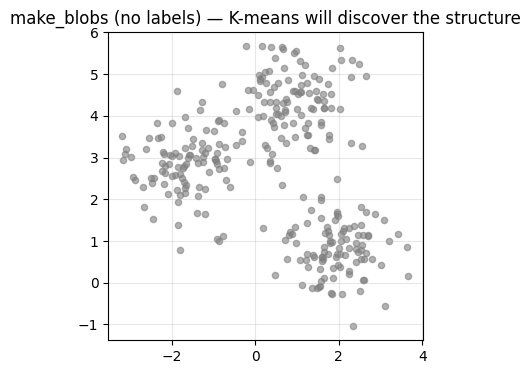

X_blob shape = (300, 2),  K = 3


In [ ]:
# Setup: 3 well-separated blobs (do not modify)
from sklearn.datasets import make_blobs

X_blob, y_blob = make_blobs(
    n_samples=300, centers=3, cluster_std=0.7, random_state=0
)
n_samples, n_features = X_blob.shape
K = 3

# Visualize the raw data — the 3 blobs we will try to recover
plt.figure(figsize=(6, 4))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c='gray', s=20, alpha=0.6)
plt.title('make_blobs (no labels) — K-means will discover the structure')
plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.show()

print(f'X_blob shape = {X_blob.shape},  K = {K}')

In [ ]:
#@title Question 1: K-means assign + update

def kmeans_assign(X, centers):
    """
    Hard-assignment step.

    Parameters:
        X:       (n, d) numpy array of points
        centers: (K, d) numpy array of cluster centers

    Returns:
        labels:  (n,) int numpy array, labels[i] in {0, ..., K-1}
                 — the index of the *nearest* center (squared Euclidean).

    Hint: use broadcasting: ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
          gives an (n, K) matrix of squared distances. Then argmin along axis=1.
    """
    ### YOUR SOLUTION HERE
    n = X.shape[0]

    K = centers.shape[0]

    dists = np.zeros((n,K))

    for k in range(K):
      diff = X-centers[k] #subtr kth center from every point, shape: (n,d)

      sqr = diff **2 #euclidian dist

      dists[:,k] = np.sum(sqr,axis = 1) #every center k, compute dist of every point store it in k

    labels = np.argmin(dists,axis=1)

    return labels




def kmeans_update(X, labels, K, prev_centers):
    """
    Center-update step.

    Parameters:
        X:            (n, d) numpy array of points
        labels:       (n,) int array in {0, ..., K-1}
        K:            number of clusters
        prev_centers: (K, d) numpy array of the centers from the previous iteration
                      — used as the fallback for empty clusters.

    Returns:
        new_centers: (K, d) numpy array — the mean of each cluster's points,
                     or prev_centers[k] if cluster k is empty this round.
    """
    ### YOUR SOLUTION HERE

    d = X.shape[1] #num of cols

    new_centers = np.zeros((K,d))

    for k in range(K):
      points_in_cluster = X[labels == k]

      if len(points_in_cluster) > 0:
        new_centers[k] = np.mean(points_in_cluster,axis=0)
      else:
        new_centers[k] = prev_centers[k]

    return new_centers

Test Case 1: assign on 4 points -> [0 0 1 1]
****** Passed 1/4 test cases ******

Test Case 2: updated centers =
[[ 0.   0.5]
 [10.  10.5]]
****** Passed 2/4 test cases ******

Converged in 6 iterations.
J history (first / last): 796.89  ->  286.41
Test Case 3: max distortion increase between iters = 0.00e+00
****** Passed 3/4 test cases ******

Test Case 4: ours / sklearn distortion = 1.0002  (sklearn J = 286.34)
****** Passed 4/4 test cases ******



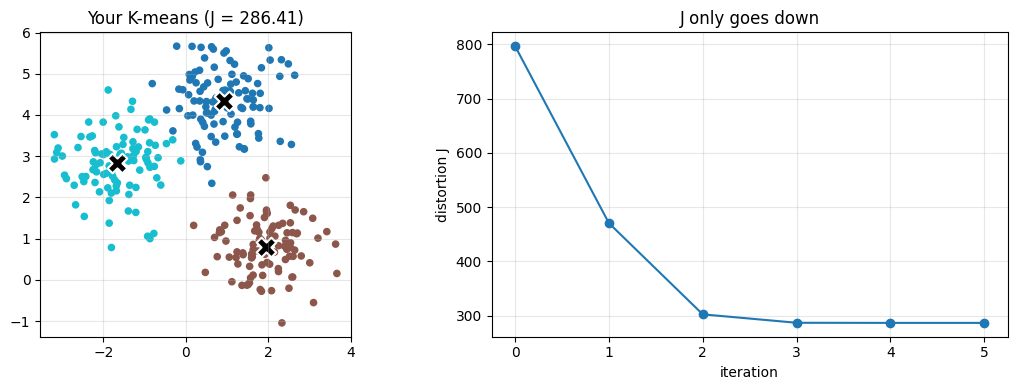

In [ ]:
# Tests: kmeans_assign + kmeans_update + small training loop

# ---- Test Case 1: tiny hand-checkable assign
X_tiny = np.array([[0.0, 0.0],
                   [0.0, 1.0],
                   [10.0, 10.0],
                   [10.0, 11.0]])
C_tiny = np.array([[0.0, 0.5],
                   [10.0, 10.5]])
labels_tiny = kmeans_assign(X_tiny, C_tiny)
print(f'Test Case 1: assign on 4 points -> {labels_tiny}')
assert labels_tiny.dtype.kind in 'iu' and labels_tiny.shape == (4,)
assert np.array_equal(labels_tiny, np.array([0, 0, 1, 1]))
print('****** Passed 1/4 test cases ******\n')

# ---- Test Case 2: update is the per-cluster mean
new_C = kmeans_update(X_tiny, labels_tiny, K=2, prev_centers=C_tiny)
print(f'Test Case 2: updated centers =\n{new_C}')
assert new_C.shape == (2, 2)
assert np.allclose(new_C[0], [0.0, 0.5])
assert np.allclose(new_C[1], [10.0, 10.5])
print('****** Passed 2/4 test cases ******\n')

# ---- Training loop (uses your two functions; do not modify)
def kmeans_run(X, K, n_iter=20, seed=0):
    rng = np.random.default_rng(seed)
    init_idx = rng.choice(X.shape[0], size=K, replace=False)
    centers = X[init_idx].copy()
    labels = np.full(X.shape[0], -1, dtype=int)
    j_history = []
    for it in range(n_iter):
        new_labels = kmeans_assign(X, centers)
        centers    = kmeans_update(X, new_labels, K, prev_centers=centers)
        # distortion J = sum of squared distances to each point's center
        diffs = X - centers[new_labels]
        j = float((diffs ** 2).sum())
        j_history.append(j)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
    return labels, centers, j_history

labels_run, centers_run, j_hist = kmeans_run(X_blob, K=3, n_iter=20, seed=0)
print(f'Converged in {len(j_hist)} iterations.')
print(f'J history (first / last): {j_hist[0]:.2f}  ->  {j_hist[-1]:.2f}')

# ---- Test Case 3: distortion is monotonically non-increasing
drops = np.diff(j_hist)
print(f'Test Case 3: max distortion increase between iters = {drops.max() if len(drops) else 0:.2e}')
assert (drops <= 1e-6).all(), 'Distortion went UP between iterations — check your assign/update.'
print('****** Passed 3/4 test cases ******\n')

# ---- Test Case 4: matches sklearn.cluster.KMeans on the same data
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_blob)
ratio = j_hist[-1] / km.inertia_
print(f'Test Case 4: ours / sklearn distortion = {ratio:.4f}  (sklearn J = {km.inertia_:.2f})')
assert 0.99 <= ratio <= 1.20, "Your final distortion is too far from sklearn's."
print('****** Passed 4/4 test cases ******\n')

# ---- Visualize the clustering you produced
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=labels_run, cmap='tab10', s=20)
axes[0].scatter(centers_run[:, 0], centers_run[:, 1],
                marker='X', s=200, c='black', edgecolors='white', linewidths=1.5)
axes[0].set_title(f'Your K-means (J = {j_hist[-1]:.2f})')
axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(j_hist, marker='o')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('distortion J')
axes[1].set_title('J only goes down')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## **Question 2: GMM Responsibilities (E-step)**

A spherical Gaussian mixture has parameters $(\pi_k, \boldsymbol{\mu}_k, \sigma_k^2)$ for $k = 1,\ldots,K$. The mixture density is
$$p(\mathbf{x}) = \sum_{k=1}^K \pi_k\,\mathcal{N}(\mathbf{x}\mid\boldsymbol{\mu}_k, \sigma_k^2 \mathbf{I}),$$
and the **E-step** computes the *responsibility* of cluster $k$ for point $i$ — the posterior probability that $\mathbf{x}_i$ came from component $k$:
$$w_{ik} = \frac{\pi_k\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k, \sigma_k^2\mathbf{I})}{\sum_{j=1}^{K}\pi_j\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j, \sigma_j^2\mathbf{I})}.$$

Implement two pure-numpy helpers:

- `gaussian_pdf(X, mu, sigma2)` — the spherical Gaussian density evaluated at every row of $\mathbf{X}$. Returns a length-$n$ array.
- `gmm_responsibilities(X, pis, mus, sigma2s)` — the $(n, K)$ matrix $w_{ik}$.

**Reminders / hints.**
- For dimension $d$, the spherical Gaussian density at $\mathbf{x}$ is $(2\pi\sigma^2)^{-d/2}\,\exp\!\bigl(-\lVert\mathbf{x}-\boldsymbol{\mu}\rVert^2/(2\sigma^2)\bigr)$.
- Each row of the responsibility matrix must **sum to 1** — the denominator normalizes per-point.
- The lecture's *tiny numerical example* (slide on the E-step): $\pi=(0.6, 0.4)$ and densities $(0.20, 0.05)$ give $w \approx (0.857, 0.143)$.

In [ ]:
#@title Question 2: gaussian_pdf + gmm_responsibilities

def gaussian_pdf(X, mu, sigma2):
    """
    Spherical multivariate Gaussian density evaluated at every row of X.

    Parameters:
        X:      (n, d) numpy array of points
        mu:     (d,)   numpy array — cluster mean
        sigma2: float  > 0 — cluster variance (scalar; spherical covariance)

    Returns:
        (n,) numpy array of densities  (2*pi*sigma2)^(-d/2) * exp(-||x - mu||^2 / (2 sigma2))
    """
    ### YOUR SOLUTION HERE
    n = X.shape[0]
    d = X.shape[1]

    diff = X - mu

    sq_dist = np.sum(diff**2, axis =1)

    coeff = (2*np.pi * sigma2)**(-d/2)

    exp = np.exp(-sq_dist / (2 * sigma2))

    return coeff * exp



def gmm_responsibilities(X, pis, mus, sigma2s):
    """
    E-step for a spherical Gaussian mixture.

    Parameters:
        X:        (n, d) numpy array of points
        pis:      (K,)   array of mixing weights, sum to 1
        mus:      (K, d) array of cluster means
        sigma2s:  (K,)   array of per-cluster spherical variances

    Returns:
        W: (n, K) numpy array of responsibilities. Each row sums to 1.

    Hint: build an (n, K) matrix of (pi_k * N(x_i|mu_k, sigma2_k)),
          then divide each row by its own sum.
    """
    ### YOUR SOLUTION HERE

    n = X.shape[0]

    K = len(pis)

    W = np.zeros((n,K))

    for k in range(K):
      W[:, k] = pis[k] * gaussian_pdf(X, mus[k], sigma2s[k])

    row_sums = np.sum(W,axis = 1,keepdims=True)

    W = W/row_sums

    return W


Test Case 1: N((0,0)|(0,0),1) = 0.159155  (expected 0.159155)
****** Passed 1/4 test cases ******

Test Case 2: lecture tiny example -> [0.85714286 0.14285714] (expected approx [0.857, 0.143])
****** Passed 2/4 test cases ******

Test Case 3: W shape = (50, 3), row-sum range = [1.0000, 1.0000]
****** Passed 3/4 test cases ******

Test Case 4: max |diff| vs sklearn = 4.44e-16
****** Passed 4/4 test cases ******



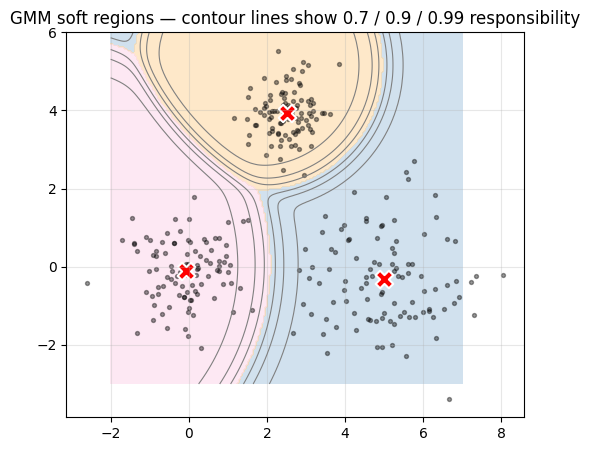

In [ ]:
# Tests: gaussian_pdf + gmm_responsibilities

# ---- Test Case 1: gaussian_pdf basic shapes / values
x = np.array([[0.0, 0.0]])
p0 = gaussian_pdf(x, mu=np.array([0.0, 0.0]), sigma2=1.0)
print(f'Test Case 1: N((0,0)|(0,0),1) = {p0[0]:.6f}  (expected {1/(2*np.pi):.6f})')
assert p0.shape == (1,)
assert np.isclose(p0[0], 1.0 / (2.0 * np.pi))
print('****** Passed 1/4 test cases ******\n')

# ---- Test Case 2: lecture 5-2 tiny numerical example
# pi = (0.6, 0.4); densities (0.20, 0.05) -> responsibilities (0.857, 0.143).
# We bypass gaussian_pdf for this test by feeding densities directly,
# so we test gmm_responsibilities with picked mus/sigma2 that reproduce
# those densities.
#
# Trick: take a 1-D point at x=0, with two Gaussians whose densities at 0
# happen to equal 0.20 and 0.05 — we just compute analytically.
# N(0|mu,sigma2) = exp(-mu^2 / (2 sigma2)) / sqrt(2 pi sigma2)
# Pick sigma2_1 such that 1/sqrt(2 pi sigma2_1) = 0.20 -> sigma2_1 = 1/(2 pi * 0.04)
# Same for cluster 2 with target density 0.05.
sigma2_1 = 1.0 / (2.0 * np.pi * 0.20 ** 2)
sigma2_2 = 1.0 / (2.0 * np.pi * 0.05 ** 2)
X_one = np.array([[0.0]])
mus_two = np.array([[0.0], [0.0]])
pis_two = np.array([0.6, 0.4])
sig2_two = np.array([sigma2_1, sigma2_2])
W = gmm_responsibilities(X_one, pis_two, mus_two, sig2_two)
print(f'Test Case 2: lecture tiny example -> {W[0]} (expected approx [0.857, 0.143])')
assert W.shape == (1, 2)
assert np.isclose(W[0, 0], 0.12 / 0.14, atol=1e-3)
assert np.isclose(W[0, 1], 0.02 / 0.14, atol=1e-3)
print('****** Passed 2/4 test cases ******\n')

# ---- Test Case 3: rows of W sum to 1 (it\'s a posterior)
rng = np.random.default_rng(7)
X_rand = rng.normal(size=(50, 2))
mus_rand = np.array([[0.0, 0.0], [3.0, 3.0], [-3.0, 3.0]])
pis_rand = np.array([0.4, 0.3, 0.3])
sig2_rand = np.array([1.0, 1.0, 1.0])
W_rand = gmm_responsibilities(X_rand, pis_rand, mus_rand, sig2_rand)
print(f'Test Case 3: W shape = {W_rand.shape}, row-sum range = '
      f'[{W_rand.sum(1).min():.4f}, {W_rand.sum(1).max():.4f}]')
assert W_rand.shape == (50, 3)
assert np.allclose(W_rand.sum(axis=1), 1.0, atol=1e-9)
print('****** Passed 3/4 test cases ******\n')

# ---- Test Case 4: matches sklearn.mixture.GaussianMixture.predict_proba
# We fit sklearn (with spherical covariance), pull out its parameters, and
# check our responsibilities exactly reproduce its predict_proba on new data.
from sklearn.mixture import GaussianMixture
X_fit = np.vstack([
    rng.normal(loc=[0, 0], scale=0.8, size=(100, 2)),
    rng.normal(loc=[5, 0], scale=1.2, size=(100, 2)),
    rng.normal(loc=[2.5, 4], scale=0.6, size=(100, 2)),
])
gmm = GaussianMixture(n_components=3, covariance_type='spherical',
                      random_state=0, max_iter=200, n_init=3).fit(X_fit)
X_query = rng.normal(size=(20, 2))
W_ours    = gmm_responsibilities(X_query,
                                 pis=gmm.weights_,
                                 mus=gmm.means_,
                                 sigma2s=gmm.covariances_)
W_sklearn = gmm.predict_proba(X_query)
print(f'Test Case 4: max |diff| vs sklearn = {np.max(np.abs(W_ours - W_sklearn)):.2e}')
assert np.allclose(W_ours, W_sklearn, atol=1e-6)
print('****** Passed 4/4 test cases ******\n')

# ---- Visualize the soft assignments on the boundary region
xx, yy = np.meshgrid(np.linspace(-2, 7, 200), np.linspace(-3, 6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
W_grid = gmm_responsibilities(grid,
                              pis=gmm.weights_,
                              mus=gmm.means_,
                              sigma2s=gmm.covariances_)
# color = argmax responsibility, alpha = max responsibility (confidence)
argmax_grid = W_grid.argmax(axis=1).reshape(xx.shape)
conf_grid   = W_grid.max(axis=1).reshape(xx.shape)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, argmax_grid, levels=[-0.5, 0.5, 1.5, 2.5], cmap='Pastel1', alpha=0.6)
plt.contour(xx, yy, conf_grid, levels=[0.7, 0.9, 0.99],
            colors='gray', linewidths=0.8)
plt.scatter(X_fit[:, 0], X_fit[:, 1], c='black', s=8, alpha=0.4)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            marker='X', s=160, c='red', edgecolors='white', linewidths=1.5)
plt.title('GMM soft regions — contour lines show 0.7 / 0.9 / 0.99 responsibility')
plt.gca().set_aspect('equal'); plt.grid(alpha=0.3)
plt.show()

---
## **Question 3: Neural-Network Forward Pass**

From lecture 6-1: a 2-layer network is just a chain of *weighted sum + activation*.

**Architecture.** 2 inputs → 3 hidden units (ReLU) → 1 output unit (sigmoid).

$$z_j = \sum_{i} W^{(1)}_{ji}\,x_i + b^{(1)}_j,\qquad h_j = \mathrm{ReLU}(z_j),$$
$$z_{\text{out}} = \sum_{j} w^{(2)}_j\,h_j + b^{(2)},\qquad p = \sigma(z_{\text{out}}).$$

Implement three helpers:

- `relu(z)` — $\max(0, z)$, element-wise.
- `sigmoid(z)` — $1 / (1 + e^{-z})$, numerically stable for both signs of $z$ (use `np.where` or `np.exp` carefully).
- `forward_pass(x, W1, b1, w2, b2)` — returns the **scalar probability** $p$ for a single input $\mathbf{x}$.

**The lecture worked example uses these weights** (slides 39–41):
$$W^{(1)} = \begin{pmatrix}0.5 & 0.3\\ -0.6 & 0.4\\ 0.8 & -0.7\end{pmatrix},\;\; b^{(1)} = (0.1, 0.2, 0.5),$$
$$w^{(2)} = (0.5, 1.0, -0.3),\;\; b^{(2)} = 0.$$

Plugging in $\mathbf{x} = (1.0, 2.0)$ should give $h = (1.2, 0.4, 0)$ (note: $h_3$ is clipped by ReLU), $z_{\text{out}} = 1.0$, and $p \approx 0.731$.

In [ ]:
#@title Question 3: relu + sigmoid + forward_pass

def relu(z):
    """Element-wise ReLU. Works on numpy arrays of any shape."""
    ### YOUR SOLUTION HERE
    return np.maximum(z, 0)


def sigmoid(z):
    """
    Numerically stable element-wise sigmoid.

    For very large positive z, the naive formula 1/(1+exp(-z)) is fine.
    For very large negative z, exp(-z) overflows — use exp(z)/(1+exp(z)) instead.
    `np.where(z >= 0, ..., ...)` is a clean way to express both branches.
    """
    ### YOUR SOLUTION HERE

    return np.where(z>= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))






def forward_pass(x, W1, b1, w2, b2):
    """
    2-layer feed-forward network: input -> ReLU hidden -> sigmoid output.

    Parameters:
        x:  (d,)  numpy array — one input
        W1: (H, d) numpy array — hidden-layer weights, row j = unit j's weights
        b1: (H,)  numpy array — hidden-layer biases
        w2: (H,)  numpy array — output-layer weights
        b2: float           — output-layer bias

    Returns:
        p: float in (0, 1) — the predicted probability sigma(z_out)
    """
    ### YOUR SOLUTION HERE

    Z1 = W1.dot(x) + b1
    A1 = relu(Z1)
    Z2 = w2.dot(A1) + b2
    p = float(sigmoid(Z2))
    return p

In [ ]:
# Tests: relu + sigmoid + forward_pass

# ---- Test Case 1: relu + sigmoid sanity
z_grid = np.array([-3.0, -0.5, 0.0, 0.5, 3.0])
print(f'Test Case 1: relu({z_grid}) = {relu(z_grid)}')
assert np.allclose(relu(z_grid), np.array([0.0, 0.0, 0.0, 0.5, 3.0]))
print(f'             sigmoid(0)   = {sigmoid(np.array([0.0]))[0]:.6f}  (expected 0.5)')
assert np.isclose(sigmoid(np.array([0.0]))[0], 0.5)
# Numerical stability: must not overflow at +/- 1000
assert np.isclose(sigmoid(np.array([1000.0]))[0], 1.0)
assert np.isclose(sigmoid(np.array([-1000.0]))[0], 0.0)
print('****** Passed 1/3 test cases ******\n')

# ---- Test Case 2: lecture 6-1 worked example (slides 39-41)
W1 = np.array([[ 0.5,  0.3],
               [-0.6,  0.4],
               [ 0.8, -0.7]])
b1 = np.array([0.1, 0.2, 0.5])
w2 = np.array([0.5, 1.0, -0.3])
b2 = 0.0
x_in = np.array([1.0, 2.0])

# Hand-computed reference values from the lecture:
# z = (1.2, 0.4, -0.1)  ->  h = (1.2, 0.4, 0)
# z_out = 0.5*1.2 + 1.0*0.4 + (-0.3)*0 + 0 = 1.0
# p = sigma(1.0) = 1/(1 + exp(-1)) ~ 0.731
p = forward_pass(x_in, W1, b1, w2, b2)
print(f'Test Case 2: lecture worked example -> p = {p:.4f}  (expected 0.7311)')
assert isinstance(p, float)
assert np.isclose(p, 0.7310585786300049, atol=1e-3)
print('****** Passed 2/3 test cases ******\n')

# ---- Test Case 3: solve XOR with hand-set weights from lecture (slides 30-31)
# h_1 = ReLU(x_1 + x_2),  h_2 = ReLU(x_1 + x_2 - 1),  y = h_1 - 2 h_2
# (we use a *sigmoid* output here, then threshold at 0.5; the lecture
#  used a linear output, so we shift the output bias to keep boundaries.)
W1_xor = np.array([[1.0, 1.0],
                   [1.0, 1.0]])
b1_xor = np.array([0.0, -1.0])
w2_xor = np.array([4.0, -8.0])    # large weights so sigmoid saturates
b2_xor = -2.0                      # tuned so y ≈ 0 at h=(0,0) and h=(2,1)

xor_inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
xor_targets = [0, 1, 1, 0]
preds = []
for x_xor, t in zip(xor_inputs, xor_targets):
    p_xor = forward_pass(np.array(x_xor, dtype=float), W1_xor, b1_xor, w2_xor, b2_xor)
    pred = int(p_xor >= 0.5)
    preds.append(pred)
    print(f'  XOR{x_xor} -> p={p_xor:.3f}  pred={pred}  target={t}')
print(f'Test Case 3: XOR predictions = {preds} (expected {xor_targets})')
assert preds == xor_targets, 'Forward pass did not solve XOR with the hand-set weights.'
print('****** Passed 3/3 test cases ******\n')

Test Case 1: relu([-3.  -0.5  0.   0.5  3. ]) = [0.  0.  0.  0.5 3. ]
             sigmoid(0)   = 0.500000  (expected 0.5)
****** Passed 1/3 test cases ******

Test Case 2: lecture worked example -> p = 0.7311  (expected 0.7311)
****** Passed 2/3 test cases ******

  XOR(0, 0) -> p=0.119  pred=0  target=0
  XOR(0, 1) -> p=0.881  pred=1  target=1
  XOR(1, 0) -> p=0.881  pred=1  target=1
  XOR(1, 1) -> p=0.119  pred=0  target=0
Test Case 3: XOR predictions = [0, 1, 1, 0] (expected [0, 1, 1, 0])
****** Passed 3/3 test cases ******



/tmp/ipykernel_82241/2643781999.py:19: RuntimeWarning: overflow encountered in exp
  return np.where(z>= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))
/tmp/ipykernel_82241/2643781999.py:19: RuntimeWarning: invalid value encountered in divide
  return np.where(z>= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))


---
# Part B — Midterm Retrospective (Lectures 1–6.1)

This is a **guided self-check**: each question (R1–R10) is a short-answer prompt mirroring the *style* of typical midterm questions. For each one:

1. Read the prompt and try to answer in 1–2 sentences (or work out the algebra) **on paper**.
2. For three questions there are **interactive widgets** to verify your answer:
   - **R4** — multiple-choice self-check on Naive Bayes' zero-probability problem.
   - **R7** — entropy curve + information-gain calculator on a 6-row dataset.
   - **R9** — step-through perceptron trace on a 4-example dataset.
3. **Worked solutions** are in the matching TA notebook — peek only after you've tried.

The interactive cells are self-loading: you can run them in any order without setting up helpers manually.


## R1. Linear regression (Lecture 1)

1. Write the **closed-form** least-squares solution $\boldsymbol{\theta}^* = ?$
2. Give the **probabilistic story**: under what noise assumption does *minimizing squared error* equal *maximum likelihood*?
3. Name **two situations** in which you would prefer gradient descent over the closed form.


## R2. Logistic regression & cross-entropy (Lecture 2)

1. Write the **average cross-entropy loss** $\ell(\mathbf{w}, b)$ for a binary classifier with $\hat p_i = \sigma(\mathbf{w}^\top\mathbf{x}_i + b)$.
2. Compute $\nabla_{\mathbf{w}}\ell$ and explain the *per-example* meaning of each term.
3. Why is **squared error a poor loss** for classification?


## R3. MLE vs MAP (Lecture 3-1)

You flip a coin four times and observe the sequence **HHTH**. Let $h$ be the probability of heads.

1. Compute $\hat h_{\text{MLE}}$.
2. Write the **posterior** $p(h \mid \text{HHTH})$ for a generic prior $p(h)$.
3. Under what conditions does **MAP beat MLE** in practice?


## R4. Naive Bayes (Lecture 3-2)

Suppose you observe the following 6-row training table with two binary features $X_1, X_2$:

| $X_1$ | $X_2$ | $Y$ |
|-------|-------|-----|
| 1 | 1 | + |
| 1 | 0 | + |
| 0 | 1 | + |
| 0 | 1 | − |
| 1 | 0 | − |
| 0 | 0 | − |

1. State the **conditional-independence assumption**.
2. Compute the priors and the four conditionals $p(x_1{=}1\mid \pm),\ p(x_2{=}1\mid \pm)$, then predict the class for $\mathbf{x}=(1, 1)$.
3. What is the **zero-probability problem** and how does Laplace smoothing solve it?


In [ ]:
# --- Part B helpers (auto-loaded if not already defined) ---
if "reveal_button" not in globals():
    import ipywidgets as widgets
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import display, Markdown, clear_output

    def reveal_button(answer_md, label="Reveal answer"):
        btn = widgets.Button(description=label, button_style="info")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                display(Markdown(answer_md))
        btn.on_click(_click)
        display(btn, out)

    def mc_quiz(question, choices, correct_idx, explanation):
        radios = widgets.RadioButtons(
            options=[(f"{chr(65 + i)}. {c}", i) for i, c in enumerate(choices)],
            value=None,
            layout=widgets.Layout(width="max-content"),
        )
        btn = widgets.Button(description="Check", button_style="primary")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                if radios.value is None:
                    print("Pick one option first.")
                    return
                mark = "Correct." if radios.value == correct_idx else (
                    f"Not quite — the correct answer is {chr(65 + correct_idx)}."
                )
                display(Markdown(f"**{mark}** {explanation}"))
        btn.on_click(_click)
        display(Markdown(f"**{question}**"), radios, btn, out)
# -----------------------------------------------------------------

#@title R4 quick check (multiple choice)
mc_quiz(
    question=r"If a single feature value never appears in the training set for class +, what happens to $p(+ \mid \mathbf{x})$ when that value is observed at test time (no smoothing)?",
    choices=[
        r"It stays roughly proportional to the prior $p(+)$.",
        r"It becomes exactly zero, regardless of the other features.",
        r"Naive Bayes drops the missing factor and uses the rest.",
        r"It becomes 1 because there is no evidence against +.",
    ],
    correct_idx=1,
    explanation=r"A zero in the product $\prod_j p(x_j \mid +)$ zeroes the whole posterior — exactly the failure mode Laplace smoothing prevents.",
)


**If a single feature value never appears in the training set for class +, what happens to $p(+ \mid \mathbf{x})$ when that value is observed at test time (no smoothing)?**

RadioButtons(layout=Layout(width='max-content'), options=(('A. It stays roughly proportional to the prior $p(+…

Button(button_style='primary', description='Check', style=ButtonStyle())

Output()

## R5. Hard-margin SVM (Lecture 4-1)

1. Write the **constraint** every training example must satisfy in a hard-margin SVM.
2. Define **support vectors** geometrically.
3. Why does a **larger margin** tend to generalize better?


## R6. Kernel SVM (Lecture 4-2)

1. For the 2-D quadratic feature map $\phi(\mathbf{x}) = (x_1^2, x_2^2, \sqrt{2}\,x_1 x_2)$, what is the corresponding **kernel** $K(\mathbf{x}, \mathbf{x}')$?
2. Why is computing $\phi(\mathbf{x})$ explicitly **expensive** for high-degree polynomials or RBF?
3. Intuitively, what does the **RBF $\gamma$** parameter control?


## R7. Decision trees + entropy (Lecture 5-1)

Consider this 6-row table with two binary features $A, B$ and binary label $y$ (4 positives, 2 negatives):

| $A$ | $B$ | $y$ |
|-----|-----|-----|
| 1 | 1 | + |
| 1 | 0 | + |
| 1 | 1 | + |
| 0 | 0 | + |
| 0 | 0 | − |
| 0 | 1 | − |

The interactive widget below lets you **explore the entropy curve** and **score either feature as a split** before checking the algebra.

1. Compute the **parent entropy** $H(S)$.
2. Compute the **information gain** of splitting on $A$.
3. Name one **pre-pruning** knob that reduces overfitting and explain in one sentence why.


In [ ]:
# --- Part B helpers (auto-loaded if not already defined) ---
if "reveal_button" not in globals():
    import ipywidgets as widgets
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import display, Markdown, clear_output

    def reveal_button(answer_md, label="Reveal answer"):
        btn = widgets.Button(description=label, button_style="info")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                display(Markdown(answer_md))
        btn.on_click(_click)
        display(btn, out)

    def mc_quiz(question, choices, correct_idx, explanation):
        radios = widgets.RadioButtons(
            options=[(f"{chr(65 + i)}. {c}", i) for i, c in enumerate(choices)],
            value=None,
            layout=widgets.Layout(width="max-content"),
        )
        btn = widgets.Button(description="Check", button_style="primary")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                if radios.value is None:
                    print("Pick one option first.")
                    return
                mark = "Correct." if radios.value == correct_idx else (
                    f"Not quite — the correct answer is {chr(65 + correct_idx)}."
                )
                display(Markdown(f"**{mark}** {explanation}"))
        btn.on_click(_click)
        display(Markdown(f"**{question}**"), radios, btn, out)
# -----------------------------------------------------------------

#@title R7 — Entropy + Information Gain explorer

# 6-row dataset (4+/2-)
DATA_AB = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1],
    [0, 0, 1],
    [0, 0, 0],
    [0, 1, 0],
])
A_COL, B_COL, Y_COL = 0, 1, 2


def H(p):
    if p <= 0 or p >= 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def show_entropy_curve(p_marker):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ps = np.linspace(0.001, 0.999, 200)
    Hs = -ps * np.log2(ps) - (1 - ps) * np.log2(1 - ps)
    ax.plot(ps, Hs, lw=2)
    ax.axvline(p_marker, color="red", ls="--", alpha=0.4)
    ax.scatter([p_marker], [H(p_marker)], color="red", s=80, zorder=5)
    ax.set_xlabel("P(+)")
    ax.set_ylabel("H(S) (bits)")
    ax.set_title(f"H({p_marker:.2f}) = {H(p_marker):.3f} bits  —  max at p = 0.5")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_split(feature_name):
    feat = A_COL if feature_name == "A" else B_COL
    n = len(DATA_AB)
    parent_p = DATA_AB[:, Y_COL].mean()
    parent_H = H(parent_p)
    pos_total = int(DATA_AB[:, Y_COL].sum())
    neg_total = n - pos_total
    rows = [f"**Split on {feature_name}:**", ""]
    rows.append(f"- Parent: {pos_total} positives, {neg_total} negatives → H = {parent_H:.3f} bits")
    weighted = 0.0
    for v in (0, 1):
        sub = DATA_AB[DATA_AB[:, feat] == v]
        if len(sub) == 0:
            continue
        pos = int(sub[:, Y_COL].sum())
        neg = len(sub) - pos
        p_v = pos / len(sub)
        H_v = H(p_v)
        weighted += len(sub) / n * H_v
        rows.append(f"- {feature_name}={v}: {pos} positives, {neg} negatives → H = {H_v:.3f}")
    ig = parent_H - weighted
    rows.append(f"- Weighted children: {weighted:.3f} bits")
    rows.append(f"- **Information Gain = {parent_H:.3f} − {weighted:.3f} = {ig:.3f} bits**")
    display(Markdown("\n".join(rows)))


display(Markdown("### Part 1 — Entropy curve\n"
                 "Drag the slider. H peaks at p = 0.5 (max uncertainty) and is 0 at p = 0 or p = 1 (pure node)."))
p_slider = widgets.FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5,
                                description="P(+) =", continuous_update=False,
                                style={"description_width": "initial"})
out1 = widgets.interactive_output(show_entropy_curve, {"p_marker": p_slider})
display(p_slider, out1)

display(Markdown("### Part 2 — Pick a split feature\n"
                 "Click **A** or **B** to score each split on the 6-row dataset. "
                 "The feature with higher IG should be the root."))
feat_picker = widgets.ToggleButtons(options=["A", "B"], description="Split on:",
                                     style={"description_width": "initial"})
out2 = widgets.interactive_output(show_split, {"feature_name": feat_picker})
display(feat_picker, out2)


### Part 1 — Entropy curve
Drag the slider. H peaks at p = 0.5 (max uncertainty) and is 0 at p = 0 or p = 1 (pure node).

FloatSlider(value=0.5, continuous_update=False, description='P(+) =', max=0.99, min=0.01, step=0.01, style=Sli…

Output()

### Part 2 — Pick a split feature
Click **A** or **B** to score each split on the 6-row dataset. The feature with higher IG should be the root.

ToggleButtons(description='Split on:', options=('A', 'B'), style=ToggleButtonsStyle(description_width='initial…

Output()

## R8. K-means + EM (Lecture 5-2)

1. Why does K-means **always converge** in finitely many iterations?
2. Give a concrete situation where **GMM beats K-means**.
3. In the EM update for the GMM means, what changes if you replace **hard counts** $\mathbb{1}[z_i = k]$ with **soft counts** $w_{ik}$?


## R9. Perceptron (Lecture 6-1)

1. State the **convergence requirement** for the basic perceptron.
2. Write the **update rule** and the *no-update* condition.
3. With $\eta = 1$, $\mathbf{w} = (0,0,0)$, **ignoring bias**, run the perceptron on the 4-example dataset below. The interactive trace lets you step through one example at a time — try to predict $\mathbf{w}$ in your head before clicking.


In [ ]:
# --- Part B helpers (auto-loaded if not already defined) ---
if "reveal_button" not in globals():
    import ipywidgets as widgets
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import display, Markdown, clear_output

    def reveal_button(answer_md, label="Reveal answer"):
        btn = widgets.Button(description=label, button_style="info")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                display(Markdown(answer_md))
        btn.on_click(_click)
        display(btn, out)

    def mc_quiz(question, choices, correct_idx, explanation):
        radios = widgets.RadioButtons(
            options=[(f"{chr(65 + i)}. {c}", i) for i, c in enumerate(choices)],
            value=None,
            layout=widgets.Layout(width="max-content"),
        )
        btn = widgets.Button(description="Check", button_style="primary")
        out = widgets.Output()
        def _click(_):
            with out:
                clear_output()
                if radios.value is None:
                    print("Pick one option first.")
                    return
                mark = "Correct." if radios.value == correct_idx else (
                    f"Not quite — the correct answer is {chr(65 + correct_idx)}."
                )
                display(Markdown(f"**{mark}** {explanation}"))
        btn.on_click(_click)
        display(Markdown(f"**{question}**"), radios, btn, out)
# -----------------------------------------------------------------

#@title R9 — Step-through perceptron trace

# 4-example, 3-D dataset
EXAMPLES = [
    (np.array([1, 1, 1]),    +1),
    (np.array([-1, 1, -1]),  -1),
    (np.array([2, 0, 1]),    +1),
    (np.array([0, -1, 1]),   -1),
]

state_p = {"step": 0, "w": np.zeros(3, dtype=int), "history": []}


def _render_perceptron(out):
    with out:
        clear_output()
        if not state_p["history"]:
            display(Markdown(f'**w = {state_p["w"].tolist()}** (initial). '
                             "Click **Next example** to start."))
            return
        rows = ["| step | x | y | w (before) | w·x | y(w·x) | rule | w (after) |",
                "|------|---|---|------------|-----|--------|------|-----------|"]
        for h in state_p["history"]:
            yd = h["y"] * h["dot"]
            rule = "no update" if h["correct"] else f'update: w + ({h["y"]:+d})·x'
            rows.append(
                f'| {h["step"]} | {h["x"]} | {h["y"]:+d} | {h["w_before"]} | '
                f'{h["dot"]} | {yd} | {rule} | **{h["w_after"]}** |'
            )
        display(Markdown("\n".join(rows)))
        done = state_p["step"]
        display(Markdown(f'**Current w = {state_p["w"].tolist()}** — '
                         f"processed {done}/{len(EXAMPLES)} examples."))


def _step(_):
    if state_p["step"] >= len(EXAMPLES):
        with out_p:
            clear_output()
            display(Markdown("All 4 examples processed. Click **Reset** to restart."))
        return
    x, y = EXAMPLES[state_p["step"]]
    w = state_p["w"]
    dot = int(np.dot(w, x))
    correct = y * dot > 0
    new_w = w if correct else w + y * x
    state_p["history"].append({
        "step": state_p["step"] + 1, "x": x.tolist(), "y": int(y),
        "w_before": w.tolist(), "dot": dot, "correct": bool(correct),
        "w_after": new_w.tolist(),
    })
    state_p["w"] = new_w
    state_p["step"] += 1
    _render_perceptron(out_p)


def _reset(_):
    state_p["step"] = 0
    state_p["w"] = np.zeros(3, dtype=int)
    state_p["history"] = []
    _render_perceptron(out_p)


btn_next = widgets.Button(description="Next example", button_style="primary")
btn_reset = widgets.Button(description="Reset", button_style="warning")
btn_next.on_click(_step)
btn_reset.on_click(_reset)
out_p = widgets.Output()

display(Markdown("**Dataset:**\n\n"
                 "| # | x         | y |\n"
                 "|---|-----------|---|\n"
                 "| 1 | (1, 1, 1)    | +1 |\n"
                 "| 2 | (-1, 1, -1)  | -1 |\n"
                 "| 3 | (2, 0, 1)    | +1 |\n"
                 "| 4 | (0, -1, 1)   | -1 |"))
display(widgets.HBox([btn_next, btn_reset]), out_p)
_render_perceptron(out_p)


**Dataset:**

| # | x         | y |
|---|-----------|---|
| 1 | (1, 1, 1)    | +1 |
| 2 | (-1, 1, -1)  | -1 |
| 3 | (2, 0, 1)    | +1 |
| 4 | (0, -1, 1)   | -1 |

Output()

## R10. Neural networks (Lecture 6-1)

1. Why must a multi-layer net include a **non-linear activation** between layers?
2. The XOR weights from Q3 use 2 hidden ReLU units. Write the closed-form solution: $h_1, h_2, y$ as functions of $x_1, x_2$.
3. In one sentence: what does **back-propagation** do, and how is it different from the SGD you used for logistic regression?


---
# Wrap-up

**What you built today.**

1. **K-means** — the cleanest example of *alternating optimization*: assign + update, monotone $J$, k-means++ init for safety.
2. **GMM E-step** — the same Bayes' rule from Naive Bayes, applied to a *hidden* class label. Soft assignments $w_{ik}$ generalize hard counts.
3. **NN forward pass** — a chain of weighted sums and squashing functions. Hidden units act as *learned features*; non-linearity is what makes depth meaningful.

**For the midterm.**

- Be ready to *hand-execute* one update of perceptron, one E-step of GMM, and one ID3 split.
- Know the *sentence-level* identity of every algorithm in the lectures-1–6.1 table on the discussion slides.
- Practice writing 1–2 sentence answers — long derivations are not what most short-answer questions ask for.

**Next week:** backpropagation — *how* the network actually learns the weights you set by hand today.
